# EXERCISE - Analysing objects in 3D
---

*Introduction to Image Analysis Workshop*

*Stefania Marcotti (stefania.marcotti@crick.ac.uk)*

*Analysing objects in 3 dimensions*

*CC-BY-SA-4.0 license: creativecommons.org/licenses/by-sa/4.0/*

*Adapted from Tom Slater (slatert2@cardiff.ac.uk)*

*[Intro to building image analysis pipelines for 3D data with Python](https://github.com/RMS-DAIM/introduction-to-image-analysis/blob/main/Scripts/Jupyter/3d_analysis.ipynb)*

---

Fill in the gaps `[...]` in the notebook and look at the Tasks as you go through to achieve the 3D analysis. Solutions are available in the Scripts folder, but please give it a good try first! Also, try not to use ChatGPT or other LLMs (but Google is allowed!).

It might be helpful to use `napari` to visualise intermediate results as you go.

## Import libraries

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage as ndi

import skimage

import pandas as pd

import napari
import tqdm as notebook_tqdm
from skimage import filters
from skimage import measure
from skimage import segmentation


## Open image

We are going to use [a demo image from `skimage`](https://scikit-image.org/docs/stable/api/skimage.data.html#skimage.data.cells3d), which contains 3 dimensions and 2 channels (membrane, ch0, and nuclei, ch1). For this exercise, we are going to subset the data to only keep the nuclear channel.

In [5]:
im_all = skimage.data.cells3d()

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Subset the image to only obtain the nuclear channel and load the result to a <code>napari</code> viewer window </div>

In [6]:
viewer = napari.Viewer()
viewer.add_image(im_all, blending='additive')

<Image layer 'im_all' at 0x220fa9a6ef0>

In [7]:
print('Object dimensions:', im_all.shape)

Object dimensions: (60, 2, 256, 256)


In [10]:
im = im_all[:,1,:,:]

In [11]:
viewer = napari.Viewer()
viewer.add_image(im, blending='additive')

<Image layer 'im' at 0x2209b509390>

## Use filters to suppress noise

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Apply a Gaussian blur and load the result to a <code>napari</code> viewer window </div>

In [29]:
im_gauss = filters.gaussian(im, sigma=5)

thresh = filters.threshold_otsu(im_gauss)

vol_thresh = im_gauss > thresh


In [30]:
viewer = napari.Viewer()
viewer.add_image(vol_thresh, blending='additive')

<Image layer 'vol_thresh' at 0x220dc0a85b0>

## Segment volumes

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Segment the nuclei using one of <code>skimage</code> default algorithms and load the result to a <code>napari</code> viewer window </div>

## Count objects

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Create a label image from the binary mask obtained in the step above and load the result to a <code>napari</code> viewer window. How many objects are there in the image? </div>

In [21]:
labels = measure.label(vol_thresh)

In [22]:
print('There are', labels.max(), 'objects in the image')

There are 13 objects in the image


In [23]:
viewer = napari.Viewer()
viewer.add_image(labels, blending='additive')

<Image layer 'labels' at 0x220c5b62770>

<div style="background-color:#c1c3d7; border-radius: 5px; padding: 10pt"><strong>Task (difficult!)</strong> We might be able to improve the quality of the segmentation with seeded watershedding. Give it a go and load the results to a <code>napari</code> viewer window. How many objects are there in the image, if we use this approach?</div>

## Perform morphological quantification

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Measure the volume and locate the centroid of each nucleus. Save the results in a pandas dataframe and plot the distribution of volumes in a histogram. </div>

    label      area  centroid-0  centroid-1  centroid-2
0       1   53813.0   38.536302   87.290060   53.777266
1       2   31644.0   33.049646  219.785899  243.953988
2       3  221597.0   34.324648  195.638610   77.364369
3       4   52664.0   34.305579  157.522786  110.541300
4       5   58863.0   31.229805  201.442893  172.854476
5       6  116333.0   36.129817   36.869633  182.974066
6       7  227957.0   34.149576  101.370851  166.020070
7       8   33376.0   35.583683   17.250090   23.723184
8       9   13128.0   31.305302  247.327239  206.986974
9      10    1209.0   32.674938  189.128205    1.434243
10     11     113.0   32.858407    0.663717  253.477876
11     12    3324.0   39.297232    3.168472  207.426294
12     13     239.0   35.213389   24.213389  254.464435


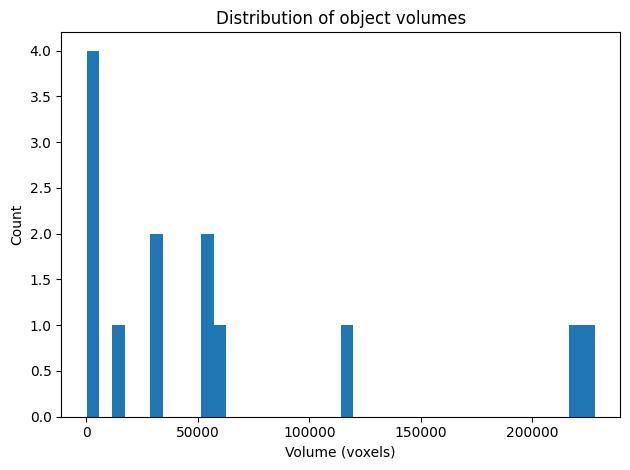

In [26]:
props = measure.regionprops_table(labels, properties=['label', 'area', 'centroid'])
props_df = pd.DataFrame(props)
print(props_df)

regions = measure.regionprops(labels)
volumes = [region.area for region in regions]

plt.hist(volumes, bins=40)
plt.xlabel('Volume (voxels)')
plt.ylabel('Count')
plt.title('Distribution of object volumes')

plt.tight_layout()